# In this notebook we explore the respone terms of the single link

In [1]:
import h5py
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("data/")
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.usetex'] = True

from lisaconstants import c
from lisaconstants.indexing import LINKS, SPACECRAFT
from pytdi.michelson import X2_ETA, Y2_ETA, Z2_ETA

from segwo.response import compute_strain2link
from segwo_utils import _link_response_boosted

from segwo_utils import InterpolatedOrbits, compute_covariance, compute_strain2x

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

import matplotlib.colors as mcolors


def symmetrical_colormap(cmap_settings, new_name = None ):
    ''' This function take a colormap and create a new one, as the concatenation of itself by a symmetrical fold.
    '''
    # get the colormap
    cmap = plt.cm.get_cmap(*cmap_settings)
    if not new_name:
        new_name = "sym_"+cmap_settings[0]  # ex: 'sym_Blues'
    
    # this defined the roughness of the colormap, 128 fine
    n= 128 
    
    # get the list of color from colormap
    colors_r = cmap(np.linspace(0, 1, n))    # take the standard colormap # 'right-part'
    colors_l = colors_r[::-1]                # take the first list of color and flip the order # "left-part"

    # combine them and build a new colormap
    colors = np.vstack((colors_l, colors_r))
    mymap = mcolors.LinearSegmentedColormap.from_list(new_name, colors)

    return mymap

cmap_settings = ('Blues', None)  # provide int instead of None to "discretize/bin" the colormap
mymap = symmetrical_colormap(cmap_settings= cmap_settings, new_name =None )



/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with h5py.File("data/processed_trajectories.h5", "r") as ds:
        t_orb_dataset   = ds["t_interp"][()]
        x_orb_dataset   = ds["spacecraft_positions"][()]
        v_orb_dataset   = ds["spacecraft_velocities"][()]
        ltts_dataset    = ds['owlt_12_23_31_13_32_21'][()]

t_orb        = t_orb_dataset
x_orb        = np.median(x_orb_dataset, axis=0)
v_orb        = np.median(v_orb_dataset, axis=0)
ltts_median  = np.median(ltts_dataset,  axis=0)

In [3]:
orbits = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                ltts=ltts_median,
                                interp_order=3)

perturbed = InterpolatedOrbits(t_orb, x_orb_dataset[0],  # Perturbation of 1 mm in position
                                spacecraft_velocities=v_orb_dataset[0],
                                ltts=ltts_dataset[0],
                                interp_order=3)

In [4]:
array_ltts = np.arange(0,365,1) * 86400.0
print("Number of points in LISA", int(array_ltts[-1]*0.25))

Number of points in LISA 7862400


# Inputs to Response

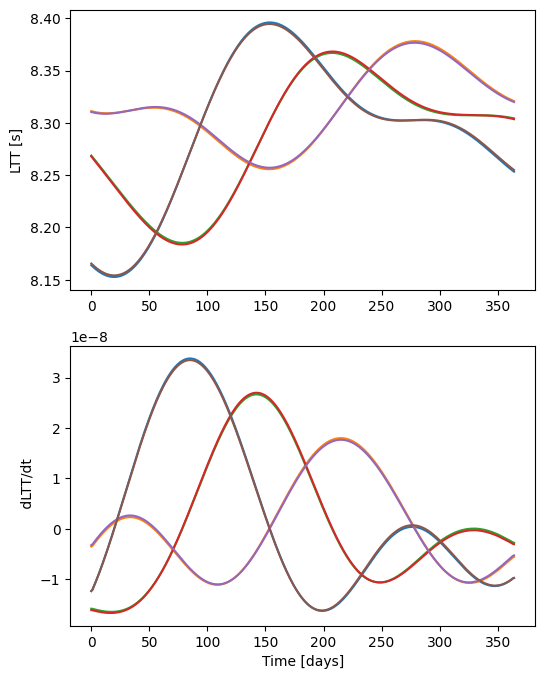

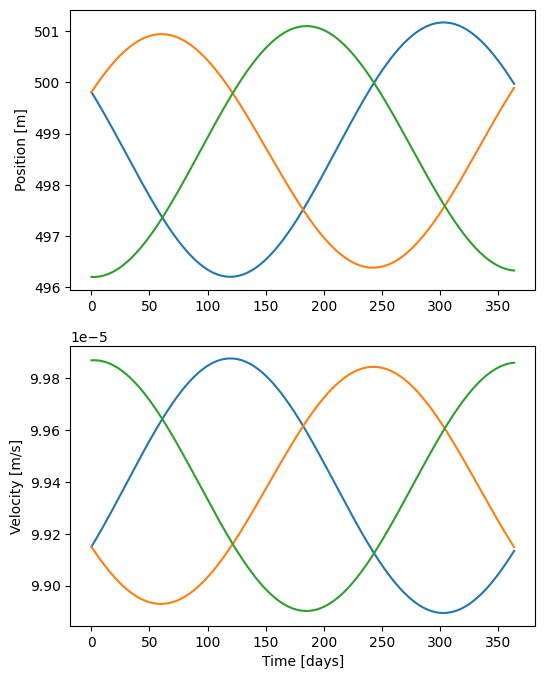

In [5]:
ltts      = orbits.compute_ltt(t=array_ltts)
positions = orbits.compute_position(t=array_ltts)
velocities = orbits.compute_velocity(t=array_ltts)

_, axes = plt.subplots(2, 1,figsize=(6,8))
for index, link in enumerate(LINKS):
    axes[0].plot(array_ltts/86400, ltts[:, index], label=link)
    axes[1].plot(array_ltts/86400, np.gradient(ltts[:, index], array_ltts), label=link)

plt.xlabel('Time [days]')
axes[0].set_ylabel('LTT [s]')
axes[1].set_ylabel(' dLTT/dt')
plt.show()

_, axes = plt.subplots(2, 1,figsize=(6,8))
for index, link in enumerate(SPACECRAFT):
    axes[0].plot(array_ltts/86400, np.linalg.norm(positions[:, index]/c, axis=1), label=link)
    axes[1].plot(array_ltts/86400, np.linalg.norm(velocities[:, index]/c, axis=1), label=link)

plt.xlabel('Time [days]')
axes[0].set_ylabel('Position [m]')
axes[1].set_ylabel('Velocity [m/s]')
plt.show()

Text(0, 0.5, ' dLTT/dt')

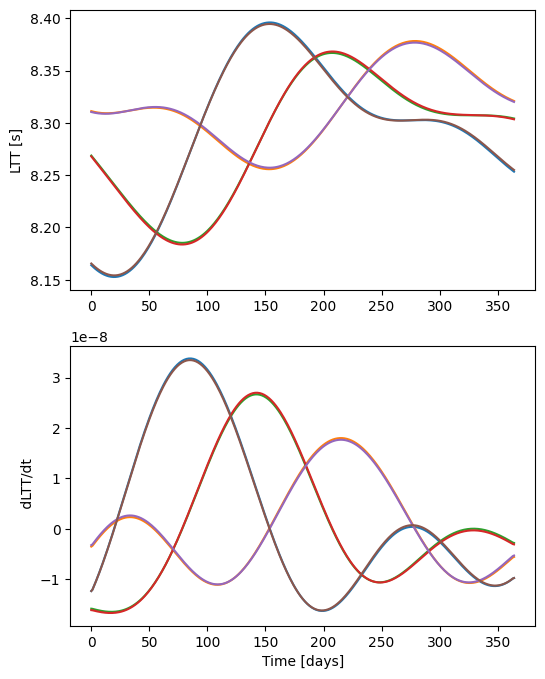

In [6]:
ltts_perturbed      = perturbed.compute_ltt(t=array_ltts)
positions_perturbed = perturbed.compute_position(t=array_ltts)
velocities_perturbed = perturbed.compute_velocity(t=array_ltts)

_, axes = plt.subplots(2, 1,figsize=(6,8))
for index, link in enumerate(LINKS):
    axes[0].plot(array_ltts/86400, ltts_perturbed[:, index], label=link)
    axes[1].plot(array_ltts/86400, np.gradient(ltts_perturbed[:, index], array_ltts), label=link)

plt.xlabel('Time [days]')
axes[0].set_ylabel('LTT [s]')
axes[1].set_ylabel(' dLTT/dt')


# Response

In [7]:
nside = 2
npix  = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
# betas, lambs = np.pi / 2 - thetas, phis
betas, lambs = np.pi / 2 - np.array([np.pi/3]), np.array([np.pi/3])
f = np.logspace(-4, 0., 500)

strain2link = compute_strain2link(f, betas, lambs, ltts, positions, method="baghi+23")
strain2link_boosted = _link_response_boosted(f, betas, lambs, ltts, positions, velocities=velocities)
strain2link_boosted_perturbed = _link_response_boosted(f, betas, lambs, ltts_perturbed, positions_perturbed, velocities=velocities_perturbed)
strain2link_boosted.shape

(365, 500, 1, 6, 2)

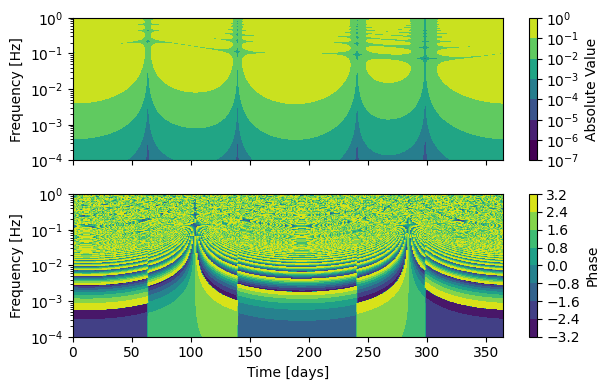

In [8]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index

response = strain2link[:, :, sky_index, link, pol]# / f
amp_map = (np.abs(response).T)
phase_map = (np.angle(response).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

with h5py.File("data/link_response_maps.h5", "w") as ds:
    ds.create_dataset("array_ltts", data=array_ltts)
    ds.create_dataset("frequencies", data=f)
    ds.create_dataset("amp_map", data=amp_map)
    ds.create_dataset("phase_map", data=phase_map)


Text(0, 0.5, 'Real part of strain2link')

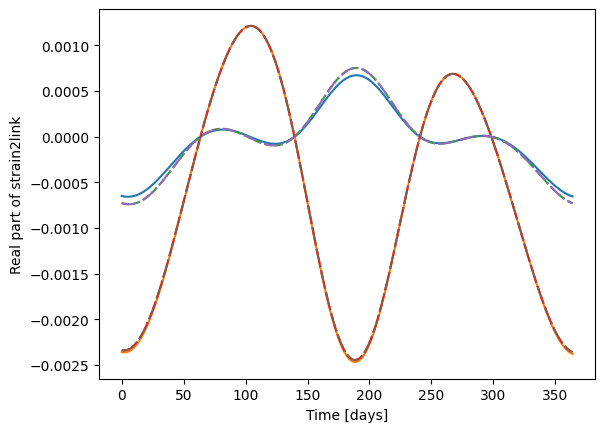

In [9]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index

plt.figure()
plt.plot(array_ltts / 86400, strain2link[:, 0, sky_index, link, pol].real)
plt.plot(array_ltts / 86400, strain2link[:, 0, sky_index, link, pol].imag)
plt.plot(array_ltts / 86400, strain2link_boosted[:, 0, sky_index, link, pol].real, '--')
plt.plot(array_ltts / 86400, strain2link_boosted[:, 0, sky_index, link, pol].imag, '--')
plt.plot(array_ltts / 86400, strain2link_boosted_perturbed[:, 0, sky_index, link, pol].real, '-.')
plt.plot(array_ltts / 86400, strain2link_boosted_perturbed[:, 0, sky_index, link, pol].imag, '-.')
plt.xlabel('Time [days]')
plt.ylabel('Real part of strain2link')


# Study relativistic impact

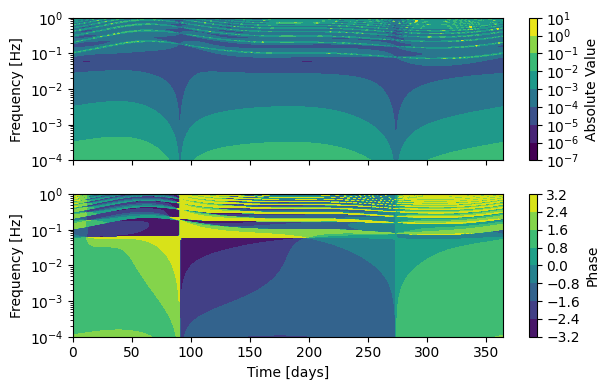

In [10]:
response_rel = (strain2link[:, :, sky_index, link, pol] - strain2link_boosted[:, :, sky_index, link, pol]) / strain2link_boosted[:, :, sky_index, link, pol]

amp_map = (np.abs(response_rel).T)
phase_map = (np.angle(response_rel).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

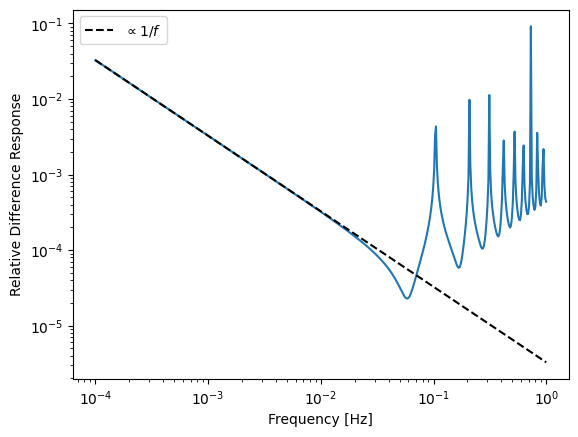

In [11]:

plt.figure()
plt.loglog(f,  amp_map[:,0], label='')
plt.loglog(f,  amp_map[0,0]*(f[0]/f), 'k--', label=r"$\propto 1/f$")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Relative Difference Response')
plt.legend()
plt.show()

# Study orbits impact

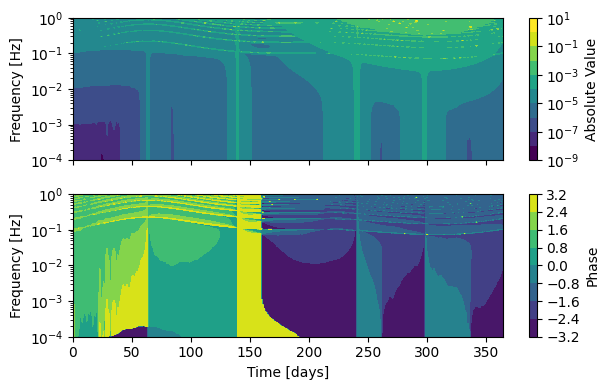

In [12]:
response_orb = (strain2link_boosted_perturbed[:, :, sky_index, link, pol] - strain2link_boosted[:, :, sky_index, link, pol]) / strain2link_boosted[:, :, sky_index, link, pol]

amp_map = (np.abs(response_orb).T)
phase_map = (np.angle(response_orb).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

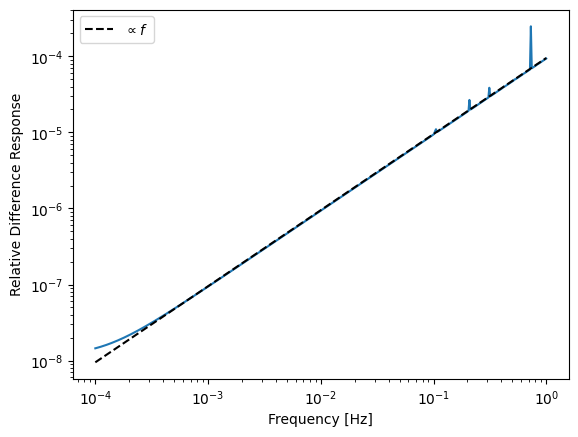

In [13]:
plt.figure()
plt.loglog(f,  amp_map[:,0], label='')
plt.loglog(f,  amp_map[100,0]*(f/f[100]), 'k--', label=r"$\propto f$")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Relative Difference Response')
plt.legend()
plt.show()

# Comparison of the effects

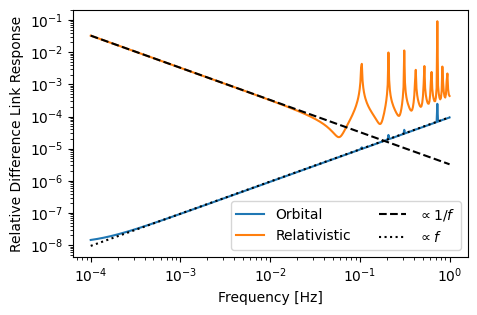

In [14]:
amp_orb = (np.abs(response_orb).T)
amp_rel = (np.abs(response_rel).T)
plt.figure(figsize=(3.25*1.5,3.25))
plt.loglog(f,  amp_orb[:,0], label='Orbital')
# plt.loglog(f,  np.mean(amp_orb,axis=1), label='Orbital')
plt.loglog(f,  amp_rel[:,0], label='Relativistic')
# plt.loglog(f,  np.mean(amp_rel,axis=1), label='Relativistic')
plt.loglog(f,  amp_rel[0,0]*(f[0]/f), 'k--', label=r"$\propto 1/f$")
plt.loglog(f,  amp_orb[100,0]*(f/f[100]), 'k:', label=r"$\propto f$")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Relative Difference Link Response')
plt.legend(ncols=2)
plt.tight_layout()
plt.savefig("paper_plots/response_comparison.png", dpi=300)

<Figure size 640x480 with 0 Axes>

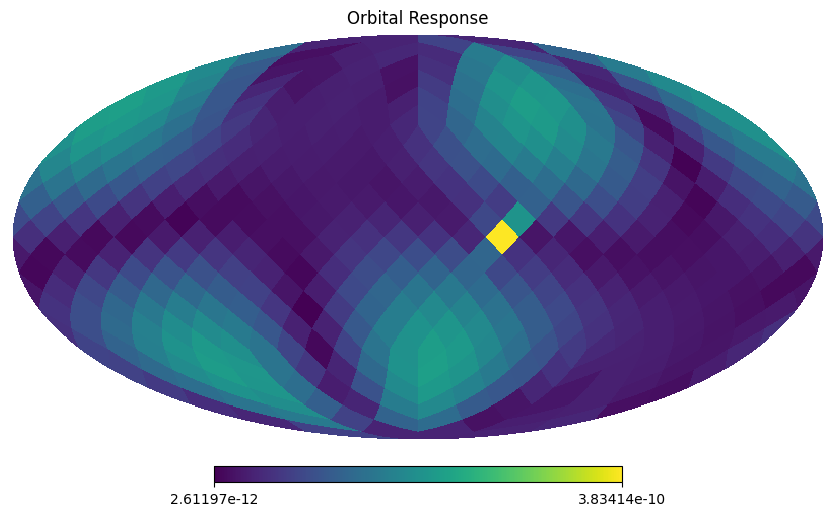

<Figure size 640x480 with 0 Axes>

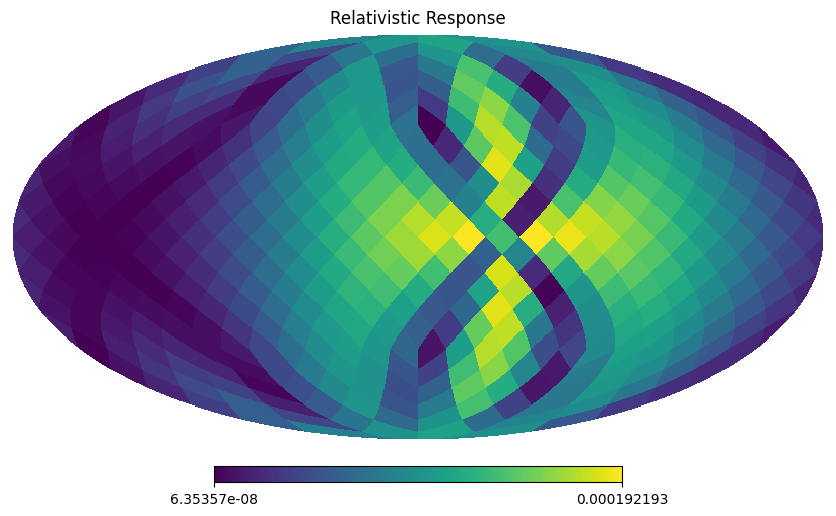

In [15]:
nside = 6
npix  = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis
f = np.logspace(-4, 0., 10)

strain2link = compute_strain2link(f, betas, lambs, ltts, positions, method="baghi+23")
strain2link_boosted = _link_response_boosted(f, betas, lambs, ltts, positions, velocities=velocities)
strain2link_boosted_perturbed = _link_response_boosted(f, betas, lambs, ltts_perturbed, positions_perturbed, velocities=velocities_perturbed)


freq_index = 0
response_orb = (strain2link_boosted_perturbed[:, freq_index, :, link, pol] - strain2link_boosted[:, freq_index, :, link, pol])# / strain2link_boosted[:, freq_index, :, link, pol]
response_rel = (strain2link[:, freq_index, :, link, pol] - strain2link_boosted[:, freq_index, :, link, pol])# / strain2link_boosted[:, freq_index, :, link, pol]
strain2link_boosted_perturbed.shape
plt.figure()
hp.mollview(np.abs(response_orb[2]), title="Orbital Response")
plt.show()
plt.figure()
hp.mollview(np.abs(response_rel[2]), title="Relativistic Response")
plt.show()


# Time evolving inner product

In [16]:
nside = 6
npix  = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis
# betas, lambs = np.pi / 2 - np.array([np.pi/3]), np.array([np.pi/3])
f = np.logspace(-4, 0., 10)

cov_AET = compute_covariance(f, ltts_median)[:,:,np.newaxis,:,:] # added an axis for sky pixels
cov_AET = cov_AET.mean(axis=0)[None,...]
inv_cov_AET = np.linalg.inv(cov_AET)

array_ltts = np.linspace(0, 15, num=128) * 86400.0

ltts      = orbits.compute_ltt(t=array_ltts)
positions = orbits.compute_position(t=array_ltts)
velocities = orbits.compute_velocity(t=array_ltts)

ltts_perturbed      = perturbed.compute_ltt(t=array_ltts)
positions_perturbed = perturbed.compute_position(t=array_ltts)
velocities_perturbed = perturbed.compute_velocity(t=array_ltts)

strain2AET_boosted = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
strain2AET_boosted_perturbed = compute_strain2x(f, betas, lambs, ltts_perturbed, positions_perturbed, velocities=velocities_perturbed)

In [17]:
strain2AET_boosted.shape, cov_AET.shape

((128, 10, 432, 3, 2), (1, 10, 1, 3, 3))

In [18]:
A_A = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET_boosted), inv_cov_AET, strain2AET_boosted).real
A_B = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET_boosted), inv_cov_AET, strain2AET_boosted_perturbed).real
B_B = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET_boosted_perturbed), inv_cov_AET, strain2AET_boosted_perturbed).real
mismatch_boost = np.abs(1 - A_B / (B_B * A_A)**0.5)
mismatch_boost.shape

(128, 10, 432)

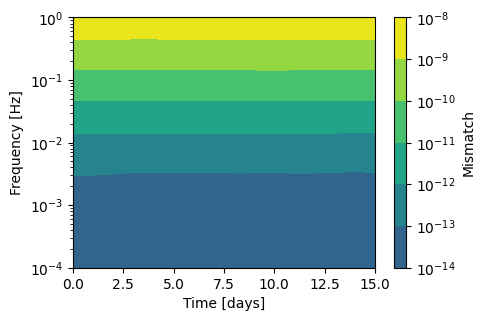

In [19]:
sky_index = 10  # Choose a specific sky location (pixel index)
plt.figure(figsize=(3.25*1.5,3.25))
plt.contourf(array_ltts / 86400, f, mismatch_boost[:,:,sky_index].T, levels=5, norm=mcolors.LogNorm(vmin=1e-16, vmax=mismatch_boost.max()))
plt.colorbar(label='Mismatch')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.yscale('log')
plt.show()

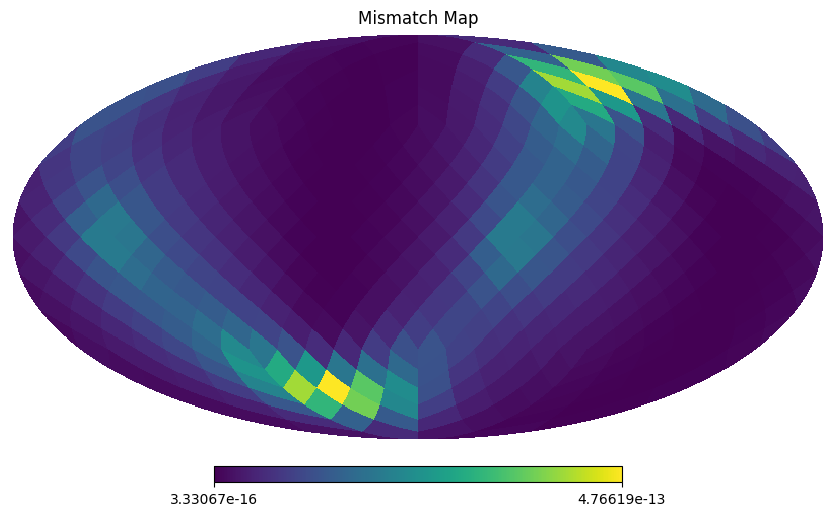

In [20]:
hp.mollview(mismatch_boost[0,0], title='Mismatch Map', cmap='viridis')

(128, 10, 432)

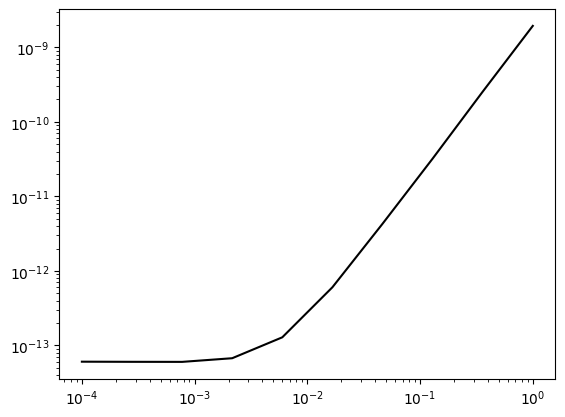

In [21]:
# [:array_ltts<15*86400]
mask_time = array_ltts<365*86400
plt.figure()
plt.loglog(f, np.mean(mismatch_boost[mask_time], axis=(0,2)), color='k', label='Response Only Mismatch')
mismatch_boost.shape

In [22]:
mismatch = {}
output_file = "gb_mismatch_results_15.0days.h5"
with h5py.File(output_file, "r") as file:
    f0_vec = file["f0_vec"][()]
    for key in file.keys():
        if key.startswith("mismatch_"):
            mismatch[key] = file[key][()]

labels = {
    "mismatch_perturbed_vs_nominal_with_nonrel": "Perturbed vs Nominal Orbits (Non-Boosted Response)",
    "mismatch_perturbed_vs_nominal_with_rel": "Perturbed vs Nominal Orbits (Boosted Response)",
    "mismatch_nonrel_vs_rel_with_perturbed": "Non-Boosted vs Boosted Response (Perturbed orbits)",
    "mismatch_nonrel_vs_rel_with_nominal": "Non-Boosted vs Boosted Response (Nominal orbits)",
    "mismatch_nonrel_vs_rel_test": "Non-Boosted. vs Boosted Response (Test)",
}


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'gb_mismatch_results_15.0days.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

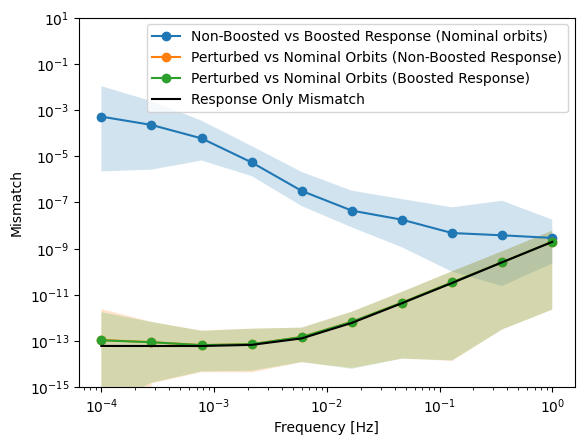

In [ ]:

plt.figure()
for key in mismatch.keys():
    if 'test' in key:
        continue
    if key == 'mismatch_nonrel_vs_rel_with_perturbed':
        continue
    y_mean = mismatch[key].mean(axis=1)
    y_min = mismatch[key].min(axis=1)
    y_max = mismatch[key].max(axis=1)
    plt.fill_between(f0_vec, y_min, y_max, alpha=0.2)
    plt.plot(f0_vec, y_mean, '-o', label=labels[key])
plt.loglog(f, np.mean(mismatch_boost[mask_time], axis=(0,2)), color='k', label='Response Only Mismatch')
plt.ylim(1e-15, 10)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Mismatch')
plt.legend()
plt.savefig("paper_plots/mismatch_comparison.png", dpi=300)
plt.show()